In [ ]:
#Import Library
import os
import urllib.request
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import torchvision.transforms as transforms

In [ ]:
#โหลด Dataset
BASE_URL = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"
CLASSES = [
    "cat", "dog", "car", "house", "tree",
    "cup", "fish", "clock", "chair", "airplane"
]

SAVE_DIR = r"C:\Users\usEr\Desktop\Drawing\data"
os.makedirs(SAVE_DIR, exist_ok=True)

for cls in CLASSES:
    filename = f"{cls}.npy"
    url = BASE_URL + filename
    save_path = os.path.join(SAVE_DIR, filename)

    if os.path.exists(save_path):
        print(f"{filename} have already")
        continue

    print(f"Downloading {filename}")
    urllib.request.urlretrieve(url, save_path)

print("\nAll datasets downloaded")

cat.npy have already
dog.npy have already
car.npy have already
house.npy have already
tree.npy have already
cup.npy have already
fish.npy have already
clock.npy have already
chair.npy have already
airplane.npy have already

All datasets downloaded


In [ ]:
#Data Augmentation
transform = transforms.Compose([
    transforms.ToPILImage(),

    transforms.RandomAffine(
        degrees=15,
        translate=(0.2, 0.2),
        scale=(0.8, 1.2),
        shear=10
    ),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),

    transforms.ToTensor(),

    transforms.RandomErasing(
        p=0.2,
        scale=(0.02, 0.1),
        ratio=(0.3, 3.3),
        value=0
    )
])

In [ ]:
#create Class
MAX_PER_CLASS = 60000

class QuickDrawDataset(Dataset):
    def __init__(self, data_dir, classes, transform=None):
        self.images = []
        self.labels = []
        self.transform = transform

        for label, cls in enumerate(classes):
            path = os.path.join(data_dir, f"{cls}.npy")
            data = np.load(path)
        
            if len(data) > MAX_PER_CLASS:
                indices = np.random.choice(len(data), MAX_PER_CLASS, replace=False)
                data = data[indices]
        
            self.images.append(data)
            self.labels.append(np.full(len(data), label))

        self.images = np.vstack(self.images)
        self.labels = np.concatenate(self.labels)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].reshape(28, 28).astype(np.uint8)
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        if self.transform:
            image = self.transform(image)
        else:
            image = torch.tensor(image, dtype=torch.float32).unsqueeze(0) / 255.0

        return image, label

In [ ]:
#Train Test Validation Split
train_dataset = QuickDrawDataset(SAVE_DIR, CLASSES, transform=transform)
val_dataset = QuickDrawDataset(SAVE_DIR, CLASSES, transform=None)
test_dataset = QuickDrawDataset(SAVE_DIR, CLASSES, transform=None)

dataset = QuickDrawDataset(SAVE_DIR, CLASSES)

train_size = int(0.7 * len(train_dataset))
val_size = int(0.15 * len(train_dataset))
test_size = len(train_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    train_dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

train_loss_list = []
val_loss_list = []
train_acc_list = []
val_acc_list = []

In [ ]:
#Model Architecture
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),


            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
        
model = CNN(num_classes=10)

In [ ]:
#Model Summary
from torchinfo import summary
summary(model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 10]                   --
├─Sequential: 1-1                        [1, 128, 1, 1]            --
│    └─Conv2d: 2-1                       [1, 32, 28, 28]           320
│    └─BatchNorm2d: 2-2                  [1, 32, 28, 28]           64
│    └─ReLU: 2-3                         [1, 32, 28, 28]           --
│    └─Conv2d: 2-4                       [1, 32, 28, 28]           9,248
│    └─BatchNorm2d: 2-5                  [1, 32, 28, 28]           64
│    └─ReLU: 2-6                         [1, 32, 28, 28]           --
│    └─MaxPool2d: 2-7                    [1, 32, 14, 14]           --
│    └─Conv2d: 2-8                       [1, 64, 14, 14]           18,496
│    └─BatchNorm2d: 2-9                  [1, 64, 14, 14]           128
│    └─ReLU: 2-10                        [1, 64, 14, 14]           --
│    └─Conv2d: 2-11                      [1, 64, 14, 14]           36,928
│ 

In [ ]:
#Trasnfer to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(num_classes=len(CLASSES)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

In [ ]:
#For Evaluation
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    loss_total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_total += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = loss_total / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [ ]:
#Training Session
epochs = 15

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    val_loss, val_acc = evaluate(model, val_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    torch.save(model.state_dict(), "drawing_weights.pth")
    torch.save(model.state_dict(), "drawing_model.pt")

Epoch 1/15: 100%|██████████████████████████████████████████████████████████████████| 3282/3282 [04:28<00:00, 12.22it/s]



Epoch 1
Train Loss: 0.4749 | Train Acc: 0.8461
Val   Loss: 0.3577 | Val   Acc: 0.8812


Epoch 2/15: 100%|██████████████████████████████████████████████████████████████████| 3282/3282 [04:23<00:00, 12.44it/s]



Epoch 2
Train Loss: 0.3211 | Train Acc: 0.8963
Val   Loss: 0.3042 | Val   Acc: 0.9001


Epoch 3/15: 100%|██████████████████████████████████████████████████████████████████| 3282/3282 [04:27<00:00, 12.28it/s]


...


Epoch 13
Train Loss: 0.2231 | Train Acc: 0.9267
Val   Loss: 0.2147 | Val   Acc: 0.9296


Epoch 14/15: 100%|█████████████████████████████████████████████████████████████████| 3282/3282 [04:29<00:00, 12.16it/s]



Epoch 14
Train Loss: 0.2221 | Train Acc: 0.9270
Val   Loss: 0.2167 | Val   Acc: 0.9292


Epoch 15/15: 100%|█████████████████████████████████████████████████████████████████| 3282/3282 [04:21<00:00, 12.56it/s]



Epoch 15
Train Loss: 0.2198 | Train Acc: 0.9279
Val   Loss: 0.2107 | Val   Acc: 0.9308


In [ ]:
#Final Accuracy
test_loss, test_acc = evaluate(model, test_loader)

print("\nFINAL TEST RESULT")
print(f"Test Accuracy: {test_acc:.4f}")


FINAL TEST RESULT
Test Accuracy: 0.9298


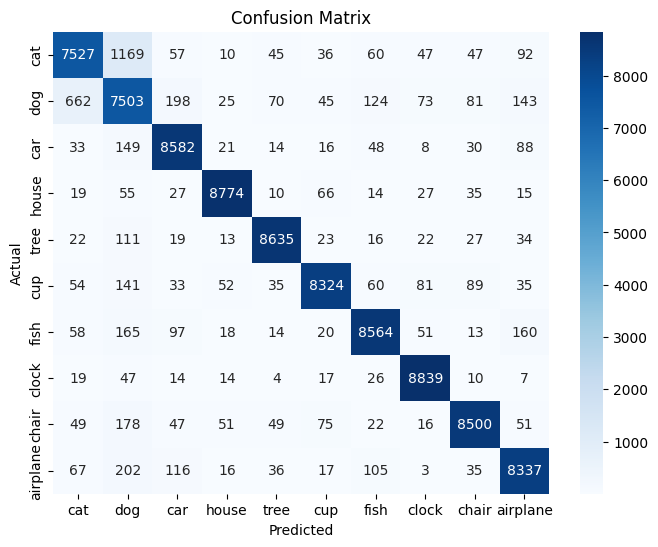


Classification Report
              precision    recall  f1-score   support

         cat       0.88      0.83      0.86      9090
         dog       0.77      0.84      0.80      8924
         car       0.93      0.95      0.94      8989
       house       0.98      0.97      0.97      9042
        tree       0.97      0.97      0.97      8922
         cup       0.96      0.93      0.95      8904
        fish       0.95      0.93      0.94      9160
       clock       0.96      0.98      0.97      8997
       chair       0.96      0.94      0.95      9038
    airplane       0.93      0.93      0.93      8934

    accuracy                           0.93     90000
   macro avg       0.93      0.93      0.93     90000
weighted avg       0.93      0.93      0.93     90000



In [ ]:
#Confusion Matrix
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASSES,
            yticklabels=CLASSES,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report")
print(classification_report(all_labels, all_preds, target_names=CLASSES))

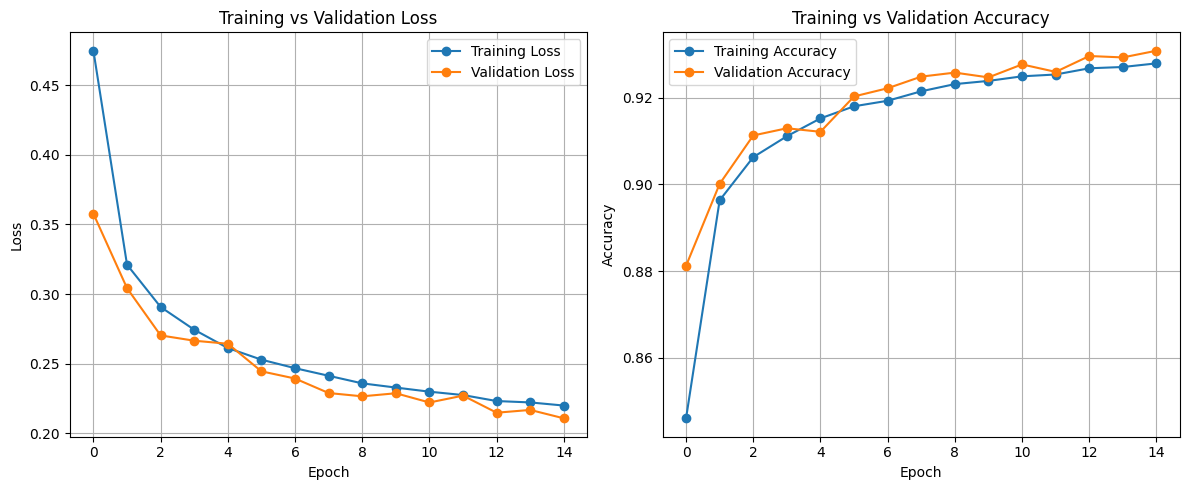

In [ ]:
#Traning Loss Acc Graph
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_loss_list, label="Training Loss", marker='o')
plt.plot(val_loss_list, label="Validation Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_acc_list, label="Training Accuracy", marker='o')
plt.plot(val_acc_list, label="Validation Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()